# 2 — Results Analysis

This notebook is the **offline analysis companion** to `1_run_attribution.ipynb`.
It requires no GPU, no model loading, and no Runpod connection.
It loads a completed run directory from `my_work/results/runs/` and produces
thesis-ready summary tables, charts, and observations.

**Prerequisites:**
1. `1_run_attribution.ipynb` has completed on Runpod.
2. The run directory has been committed and pushed to GitHub.
3. You have pulled the latest changes locally (`git pull`).

Set `RUN_ID` in the Configuration cell below to the run you want to analyse.

---

## Imports

Standard analysis stack only — no GPU dependencies.

In [1]:
import csv
import json
import os
import sys
from pathlib import Path
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

print('Imports OK')
print(f'pandas  {pd.__version__}')
print(f'matplotlib  {plt.matplotlib.__version__}')

Imports OK
pandas  3.0.2
matplotlib  3.10.9


---

## Configuration

Set `RUN_ID` to the run you want to analyse. Leave it as `None` to automatically select the
most recent run in the results directory.

In [2]:
# Set to a specific run_id string, or None to auto-select the most recent run.
RUN_ID: str | None = None

def _find_results_root() -> Path:
    """Locate my_work/results/runs/ from CWD or common workspace paths."""
    cwd = Path.cwd().resolve()
    candidates = []
    for parent in [cwd, *cwd.parents]:
        candidates.append(parent / 'my_work' / 'results' / 'runs')
    for root in [Path('/workspace'), Path('/root')]:
        if root.is_dir():
            try:
                for child in root.iterdir():
                    if child.is_dir():
                        candidates.append(child / 'my_work' / 'results' / 'runs')
            except Exception:
                pass
    candidates.append(
        Path('/Users/Lacus/Documents/ELTE/Thesis/circuit-tracer-main/my_work/results/runs')
    )
    for c in candidates:
        if c.is_dir():
            return c
    raise FileNotFoundError(
        f'Could not locate my_work/results/runs/. CWD={cwd}. '
        'Run 1_run_attribution.ipynb first and pull its outputs.'
    )


RUNS_ROOT = _find_results_root()
print(f'Runs root: {RUNS_ROOT}')

available_runs = sorted([d.name for d in RUNS_ROOT.iterdir() if d.is_dir()])
print(f'Available runs ({len(available_runs)}):')
for r in available_runs:
    print(f'  {r}')

if RUN_ID is None:
    RUN_ID = available_runs[-1]
    print(f'\nAuto-selected most recent run: {RUN_ID}')
else:
    assert RUN_ID in available_runs, f'Run not found: {RUN_ID}'
    print(f'\nSelected run: {RUN_ID}')

RUN_DIR = RUNS_ROOT / RUN_ID

Runs root: /workspace/thesis_circuit_breaker/my_work/results/runs
Available runs (3):
  20260426_073643_gemma2-2b_Phase_1_pilot_question_b
  20260426_080408_gemma2-2b_Phase_1_pilot_question_b
  gemma2-2b_Phase_1_pilot_question_bank_90af04a08f99

Auto-selected most recent run: gemma2-2b_Phase_1_pilot_question_bank_90af04a08f99


---

## Load Run Artifacts

All tables and metadata are loaded from the run directory. No model is needed.

In [3]:
manifest   = json.loads((RUN_DIR / 'manifest.json').read_text())
_rc = RUN_DIR / 'run_config_snapshot.json'
_legacy = RUN_DIR / 'questions_snapshot.json'
if _rc.is_file():
    _run_cfg = json.loads(_rc.read_text())
    snapshot = _run_cfg['question_bank']
else:
    snapshot = json.loads(_legacy.read_text())
summary    = json.loads((RUN_DIR / 'tables' / 'summary_metrics.json').read_text())

df_baseline  = pd.read_csv(RUN_DIR / 'tables' / 'baseline_results.csv')
df_features  = pd.read_csv(RUN_DIR / 'tables' / 'top_features.csv')
df_frequency = pd.read_csv(RUN_DIR / 'tables' / 'feature_frequency.csv')
df_interv    = pd.read_csv(RUN_DIR / 'tables' / 'interventions.csv')

QUESTIONS       = snapshot['questions']
TEMPLATES       = snapshot['templates']
ACTIVE_TEMPLATE = snapshot['metadata']['active_template']

print(f"Run ID          : {manifest['run_id']}")
print(f"Timestamp (UTC) : {manifest['timestamp_utc']}")
print(f"Git SHA         : {manifest['git_sha']}")
print(f"Model           : {manifest['model_name']}")
print(f"Transcoder      : {manifest['transcoder_name']}")
print(f"Backend         : {manifest['backend']}")
print(f"Active template : {ACTIVE_TEMPLATE}")
print(f"Questions       : {manifest['n_questions']}")
print(f"Baseline rows   : {len(df_baseline)}")
print(f"Top-feature rows: {len(df_features)}")
print(f"Frequency rows  : {len(df_frequency)}")
print(f"Intervention rows: {len(df_interv)}")

Run ID          : gemma2-2b_Phase_1_pilot_question_bank_90af04a08f99
Timestamp (UTC) : 2026-04-26T12:04:43.620926+00:00
Git SHA         : ae11766
Model           : google/gemma-2-2b
Transcoder      : gemma
Backend         : transformerlens
Active template : T1
Questions       : 8
Baseline rows   : 24
Top-feature rows: 160
Frequency rows  : 68
Intervention rows: 56


---

## Section 1 — Baseline Analysis

We examine the model's unaided accuracy and prediction margins across all questions and templates.

A positive margin means the model predicted `True`. The magnitude indicates confidence.
Questions where the model is *wrong with high confidence* (large margin, wrong label) are the
most interesting cases for circuit analysis because the circuit is clearly executing but producing
the incorrect answer.

In [4]:
print('=== BASELINE ACCURACY BY TEMPLATE ===')
for tkey, stats in summary['accuracy_by_template'].items():
    print(f"  {tkey}: {stats['correct']}/{stats['total']} ({stats['pct']:.1f}%)")

print()
print(f'=== BASELINE MARGINS — TEMPLATE {ACTIVE_TEMPLATE} ===')
df_active = df_baseline[df_baseline['template'] == ACTIVE_TEMPLATE].copy()
df_active['sign'] = df_active['margin'].apply(lambda m: '+' if m > 0 else '-')
df_active['ok']   = df_active['correct'].apply(lambda c: 'OK' if c else 'WRONG')

print(df_active[['id', 'label', 'logit_true', 'logit_false', 'margin', 'ok']].to_string(index=False))

=== BASELINE ACCURACY BY TEMPLATE ===
  T1: 4/8 (50.0%)
  T2: 4/8 (50.0%)
  T3: 4/8 (50.0%)

=== BASELINE MARGINS — TEMPLATE T1 ===
   id  label  logit_true  logit_false  margin    ok
TI-01   True      24.125       22.000   2.125    OK
TI-02  False      24.000       22.125   1.875 WRONG
TI-03   True      24.125       22.000   2.125    OK
TI-04  False      24.000       22.000   2.000 WRONG
TI-05   True      23.875       22.125   1.750    OK
TI-06  False      24.000       22.375   1.625 WRONG
TI-07   True      23.500       21.500   2.000    OK
TI-08  False      24.375       22.125   2.250 WRONG


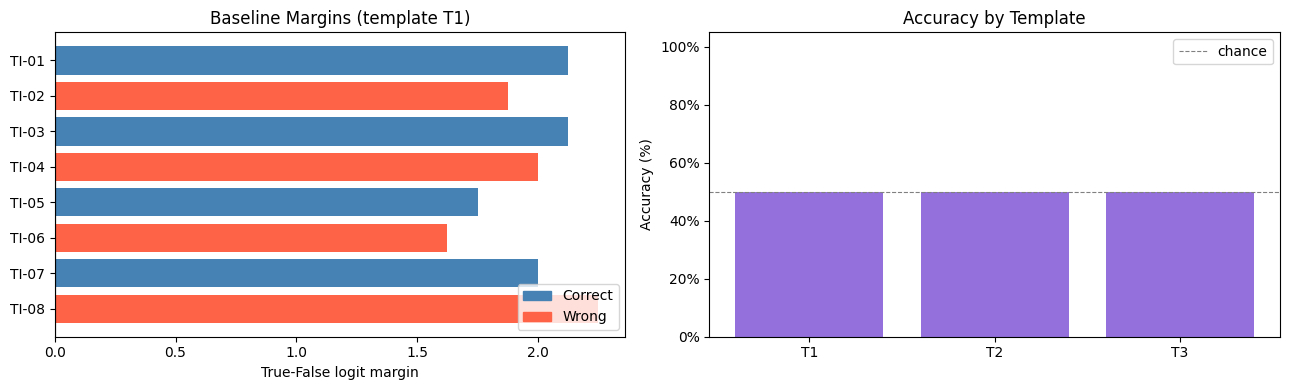

Figure saved to /workspace/thesis_circuit_breaker/my_work/results/runs/gemma2-2b_Phase_1_pilot_question_bank_90af04a08f99/tables/baseline_overview.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: margin by question ──────────────────────────────────────────────────
ax = axes[0]
colors = ['steelblue' if c else 'tomato' for c in df_active['correct']]
ax.barh(df_active['id'], df_active['margin'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('True-False logit margin')
ax.set_title(f'Baseline Margins (template {ACTIVE_TEMPLATE})')
ax.invert_yaxis()
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color='steelblue', label='Correct'),
    plt.Rectangle((0, 0), 1, 1, color='tomato',    label='Wrong'),
]
ax.legend(handles=legend_handles, loc='lower right')

# ── Right: accuracy by template ───────────────────────────────────────────────
ax2  = axes[1]
tkeys = list(summary['accuracy_by_template'].keys())
pcts  = [summary['accuracy_by_template'][t]['pct'] for t in tkeys]
ax2.bar(tkeys, pcts, color='mediumpurple')
ax2.set_ylim(0, 105)
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy by Template')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.axhline(50, color='gray', linestyle='--', linewidth=0.8, label='chance')
ax2.legend()

plt.tight_layout()
plt.savefig(RUN_DIR / 'tables' / 'baseline_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to', RUN_DIR / 'tables' / 'baseline_overview.png')

---

## Section 2 — Top Feature Analysis

For each question, the runner notebook saved the top `TOP_N` features ranked by multi-hop influence.
Here we examine:

- Which features appear at the top for each question.
- Whether specific layers are over-represented.
- How influence score magnitudes compare across questions (using the normalised `score_norm` column).

The `score_norm` column rescales each question's scores to [-1, 1] so that questions with
small probability gaps (low `prob` weight) remain comparable to high-confidence questions.

In [6]:
print(f'Top features table: {len(df_features)} rows across {df_features["qid"].nunique()} questions')
print()
print('Top 5 features by score_norm for each question:')
print()
for qid in sorted(df_features['qid'].unique()):
    sub = df_features[df_features['qid'] == qid].nlargest(5, 'score_norm')
    label = next(q['label'] for q in QUESTIONS if q['id'] == qid)
    print(f"  {qid} (label={'True' if label else 'False'}):")
    for _, row in sub.iterrows():
        print(f"    rank={int(row['rank']):2}  ({int(row['layer'])}, {int(row['position'])}, {int(row['feature_idx']):<8})  score_norm={row['score_norm']:+.4f}  {row['sign']}")
    print()

Top features table: 160 rows across 8 questions

Top 5 features by score_norm for each question:

  TI-01 (label=True):
    rank= 1  (0, 2, 16200   )  score_norm=+1.0000  pos
    rank= 2  (0, 31, 6051    )  score_norm=+0.8289  pos
    rank= 3  (24, 31, 4640    )  score_norm=+0.7697  pos
    rank= 4  (1, 28, 14349   )  score_norm=+0.7321  pos
    rank= 5  (0, 1, 16229   )  score_norm=+0.7089  pos

  TI-02 (label=False):
    rank= 1  (0, 2, 16200   )  score_norm=+1.0000  pos
    rank= 2  (0, 31, 6051    )  score_norm=+0.8151  pos
    rank= 3  (24, 31, 4640    )  score_norm=+0.7925  pos
    rank= 4  (1, 28, 14349   )  score_norm=+0.7345  pos
    rank= 5  (0, 1, 16229   )  score_norm=+0.7102  pos

  TI-03 (label=True):
    rank= 1  (0, 2, 16200   )  score_norm=+1.0000  pos
    rank= 2  (0, 34, 6051    )  score_norm=+0.8423  pos
    rank= 3  (24, 34, 4640    )  score_norm=+0.7767  pos
    rank= 4  (1, 31, 14349   )  score_norm=+0.7402  pos
    rank= 5  (0, 1, 16229   )  score_norm=+0.7038  

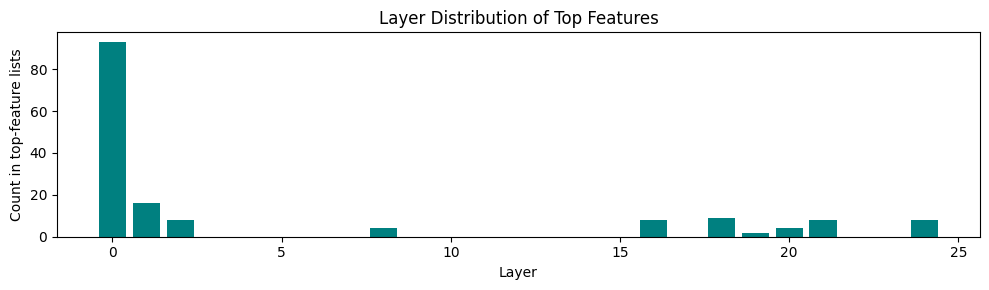

Figure saved.


In [7]:
# Layer distribution of top features
layer_counts = df_features.groupby('layer').size().reset_index(name='count')
layer_counts = layer_counts.sort_values('layer')

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(layer_counts['layer'], layer_counts['count'], color='teal')
ax.set_xlabel('Layer')
ax.set_ylabel('Count in top-feature lists')
ax.set_title('Layer Distribution of Top Features')
plt.tight_layout()
plt.savefig(RUN_DIR / 'tables' / 'layer_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

---

## Section 3 — Cross-Question Feature Recurrence

Features that recur across many questions are candidates for shared circuit components —
internal features the model uses broadly for this class of reasoning rather than for any
single prompt.

The frequency table records how many questions each feature appeared in and which ones.

In [8]:
df_freq_sorted = df_frequency.sort_values('frequency', ascending=False)

print('Features appearing in 2+ questions:')
print()
top_recurring = df_freq_sorted[df_freq_sorted['frequency'] >= 2]
print(top_recurring[['layer', 'position', 'feature_idx', 'frequency', 'question_ids']].to_string(index=False))
print()
print(f'Total unique features: {len(df_frequency)}')
print(f'Recurring (freq >= 2): {len(top_recurring)}')
print(f'Recurring (freq >= 3): {len(df_freq_sorted[df_freq_sorted["frequency"] >= 3])}')

Features appearing in 2+ questions:

 layer  position  feature_idx  frequency                                    question_ids
     0         2        16200          8 TI-01,TI-02,TI-03,TI-04,TI-05,TI-06,TI-07,TI-08
     0         1        16229          8 TI-01,TI-02,TI-03,TI-04,TI-05,TI-06,TI-07,TI-08
     1         1        11660          8 TI-01,TI-02,TI-03,TI-04,TI-05,TI-06,TI-07,TI-08
     0         1         6083          8 TI-01,TI-02,TI-03,TI-04,TI-05,TI-06,TI-07,TI-08
     0         1         6421          8 TI-01,TI-02,TI-03,TI-04,TI-05,TI-06,TI-07,TI-08
     0         1        11167          8 TI-01,TI-02,TI-03,TI-04,TI-05,TI-06,TI-07,TI-08
     0         1         6381          7       TI-01,TI-02,TI-03,TI-04,TI-05,TI-07,TI-08
     0         1         8489          6             TI-01,TI-02,TI-03,TI-04,TI-07,TI-08
     0         1        10345          5                   TI-01,TI-02,TI-05,TI-06,TI-08
     0         5        10815          4                         TI-01,TI

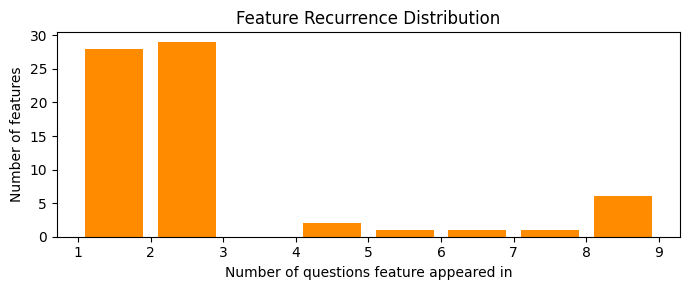

Figure saved.


In [9]:
# Recurrence frequency histogram
fig, ax = plt.subplots(figsize=(7, 3))
max_freq = int(df_frequency['frequency'].max())
ax.hist(df_frequency['frequency'], bins=range(1, max_freq + 2), color='darkorange', rwidth=0.8)
ax.set_xlabel('Number of questions feature appeared in')
ax.set_ylabel('Number of features')
ax.set_title('Feature Recurrence Distribution')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.savefig(RUN_DIR / 'tables' / 'recurrence_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

---

## Section 4 — Intervention Analysis

Circuit interventions test whether the recurring features are causally responsible for the
model's True/False decision. We examine:

- **Amplify (5x)**: did the True-False margin increase (for questions where True features were amplified)?
- **Ablate (0x)**: did the margin decrease or the prediction flip?

A consistent directional effect across multiple questions supports the causal interpretation.

In [10]:
# Cell A — Group summary (aligned vs opposed)
print('=== GROUP INTERVENTION SUMMARY ===')
print(f"{'Key':<36} {'avg_delta':>10}  {'n_flipped':>10}  {'total':>6}")
print('-' * 68)
for direction in ['aligned', 'opposed']:
    for itype in ['amplify_5x', 'ablate']:
        key = f'group_{direction}_{itype}'
        stats = summary.get('intervention_summary', {}).get(key)
        if stats:
            print(f"  {key:<34} {stats['avg_delta_margin']:>+10.4f}  "
                  f"{stats['n_flipped']:>10}  {stats['total']:>6}")

print()
print('=== GROUP PER-QUESTION DETAILS ===')
group_df = df_interv[df_interv['scope'] == 'group']
cols = ['id', 'label', 'intervention', 'direction', 'margin_before', 'margin_after', 'delta_margin', 'flipped']
print(group_df[cols].to_string(index=False))

=== GROUP INTERVENTION SUMMARY ===
Key                                   avg_delta   n_flipped   total
--------------------------------------------------------------------
  group_aligned_amplify_5x              -0.0156           0       8
  group_aligned_ablate                  -0.0469           0       8
  group_opposed_amplify_5x              +0.0156           0       8
  group_opposed_ablate                  +0.0000           0       8

=== GROUP PER-QUESTION DETAILS ===
   id  label intervention direction  margin_before  margin_after  delta_margin  flipped
TI-01   True   amplify_5x   aligned          2.125         2.000        -0.125    False
TI-01   True       ablate   aligned          2.125         2.000        -0.125    False
TI-01   True   amplify_5x   opposed          2.125         2.125         0.000    False
TI-01   True       ablate   opposed          2.125         2.125         0.000    False
TI-02  False   amplify_5x   aligned          1.875         1.875         0.000  

In [11]:
# Cell B — Single-feature summary
single_df = df_interv[df_interv['scope'] == 'single'].copy()

if single_df.empty:
    print('No single-feature intervention records found.')
else:
    print('=== SINGLE-FEATURE INTERVENTION SUMMARY ===')
    agg = (single_df
           .groupby(['feature_key', 'intervention'])['delta_margin']
           .agg(['mean', 'count'])
           .rename(columns={'mean': 'avg_delta', 'count': 'n'})
           .reset_index())
    print(agg.to_string(index=False))

    print()
    print('=== SINGLE-FEATURE PER-QUESTION DETAILS ===')
    cols = ['id', 'label', 'feature_key', 'intervention', 'margin_before', 'margin_after', 'delta_margin', 'flipped']
    print(single_df[cols].sort_values(['feature_key', 'intervention']).to_string(index=False))

=== SINGLE-FEATURE INTERVENTION SUMMARY ===
  feature_key intervention  avg_delta  n
(0, 1, 16229)       ablate   -0.06250  4
(0, 1, 16229)   amplify_5x   -0.03125  4
(0, 2, 16200)       ablate   -0.09375  4
(0, 2, 16200)   amplify_5x   -0.31250  4
(1, 1, 11660)       ablate   -0.06250  4
(1, 1, 11660)   amplify_5x   -0.28125  4

=== SINGLE-FEATURE PER-QUESTION DETAILS ===
   id  label   feature_key intervention  margin_before  margin_after  delta_margin  flipped
TI-01   True (0, 1, 16229)       ablate          2.125         2.000        -0.125    False
TI-03   True (0, 1, 16229)       ablate          2.125         2.000        -0.125    False
TI-05   True (0, 1, 16229)       ablate          1.750         1.750         0.000    False
TI-07   True (0, 1, 16229)       ablate          2.000         2.000         0.000    False
TI-01   True (0, 1, 16229)   amplify_5x          2.125         2.000        -0.125    False
TI-03   True (0, 1, 16229)   amplify_5x          2.125         2.125    

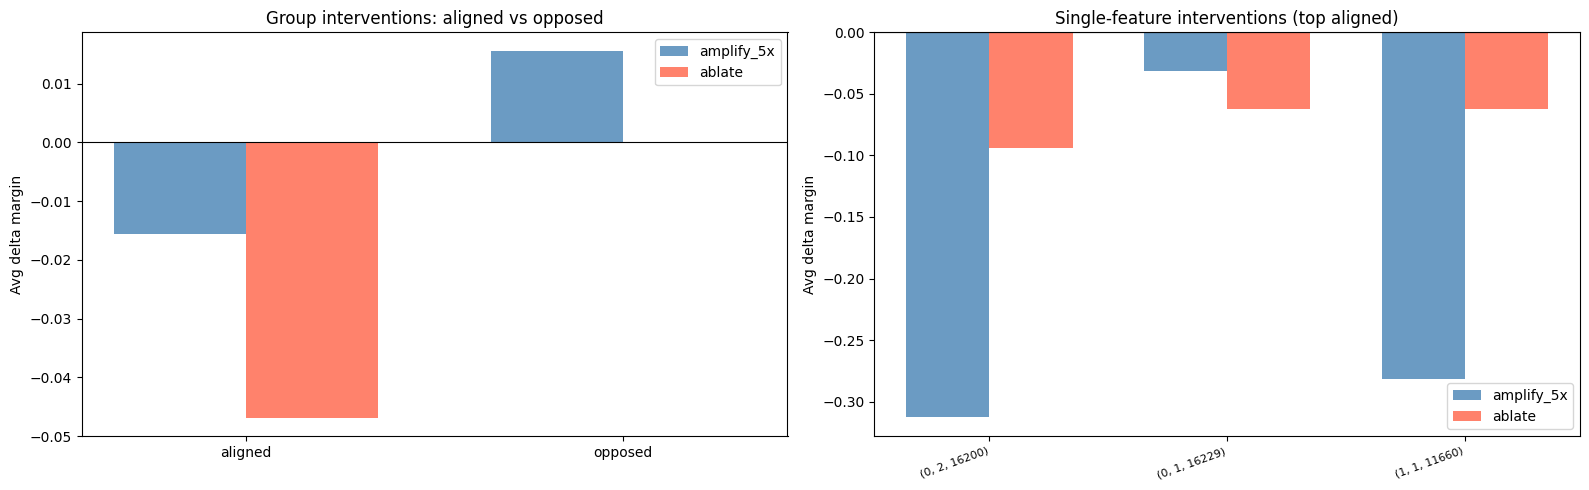

Figure saved to /workspace/thesis_circuit_breaker/my_work/results/runs/gemma2-2b_Phase_1_pilot_question_bank_90af04a08f99/tables/intervention_deltas.png


In [12]:
# Cell C — Two-panel intervention plot
group_df  = df_interv[df_interv['scope'] == 'group']
single_df = df_interv[df_interv['scope'] == 'single']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left panel: group aligned vs opposed ──────────────────────────────────
ax = axes[0]
labels_plot = []
amp_deltas  = []
abl_deltas  = []

for direction in ['aligned', 'opposed']:
    for itype, deltas_list in [('amplify_5x', amp_deltas), ('ablate', abl_deltas)]:
        subset = group_df[(group_df['direction'] == direction) & (group_df['intervention'] == itype)]
        avg    = subset['delta_margin'].mean() if not subset.empty else 0.0
        deltas_list.append(avg)
    labels_plot.append(direction)

x     = range(len(labels_plot))
width = 0.35
ax.bar([xi - width/2 for xi in x], amp_deltas, width, label='amplify_5x', color='steelblue', alpha=0.8)
ax.bar([xi + width/2 for xi in x], abl_deltas, width, label='ablate',     color='tomato',    alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(labels_plot)
ax.set_ylabel('Avg delta margin')
ax.set_title('Group interventions: aligned vs opposed')
ax.legend()

# ── Right panel: single-feature deltas for top-K features ─────────────────
ax = axes[1]
if not single_df.empty:
    feat_keys = single_df['feature_key'].unique()
    x2        = range(len(feat_keys))
    amp2      = []
    abl2      = []
    for fk in feat_keys:
        sub = single_df[single_df['feature_key'] == fk]
        amp2.append(sub[sub['intervention'] == 'amplify_5x']['delta_margin'].mean() if not sub[sub['intervention'] == 'amplify_5x'].empty else 0.0)
        abl2.append(sub[sub['intervention'] == 'ablate']['delta_margin'].mean()      if not sub[sub['intervention'] == 'ablate'].empty      else 0.0)
    ax.bar([xi - width/2 for xi in x2], amp2, width, label='amplify_5x', color='steelblue', alpha=0.8)
    ax.bar([xi + width/2 for xi in x2], abl2, width, label='ablate',     color='tomato',    alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(list(x2))
    ax.set_xticklabels([str(fk) for fk in feat_keys], rotation=20, ha='right', fontsize=8)
    ax.set_ylabel('Avg delta margin')
    ax.set_title('Single-feature interventions (top aligned)')
    ax.legend()
else:
    ax.text(0.5, 0.5, 'No single-feature data', ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
out_path = RUN_DIR / 'tables' / 'intervention_deltas.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved to {out_path}')

---

## Section 5 — Key Observations

This section is a space for you to record your interpretation of the results.
The prompts below suggest useful comparisons. Replace or extend them as you develop insights.

Questions to address:

1. **Accuracy**: Does the model distinguish True from False in this domain? Is there a template effect?
2. **Top features**: Are there features that consistently appear in the top-5 across most questions? What layers are they in?
3. **Recurrence**: How many features recur across 3 or more questions? Is recurrence stronger for True-labelled or False-labelled questions?
4. **Interventions**: Did amplification consistently increase the True-False margin? Did ablation reduce or flip predictions? Is the effect stronger for True or False items?
5. **Interpretation**: Based on Neuronpedia links in the attribution table, can any recurring features be labelled semantically?

In [13]:
# Workspace — add your analysis and notes here.


---

## Appendix — Run Metadata

In [14]:
print(json.dumps(manifest, indent=2))

{
  "run_id": "gemma2-2b_Phase_1_pilot_question_bank_90af04a08f99",
  "timestamp_utc": "2026-04-26T12:04:43.620926+00:00",
  "git_sha": "ae11766",
  "notebook": "1_run_attribution.ipynb",
  "model_name": "google/gemma-2-2b",
  "transcoder_name": "gemma",
  "backend": "transformerlens",
  "dtype": "bfloat16",
  "active_template": "T1",
  "n_questions": 8,
  "attr_batch_size": 128,
  "attr_max_feature_nodes": 8192,
  "attr_offload": "disk",
  "recurring_threshold": 3,
  "top_k_intervention": 10,
  "top_n_features": 20,
  "config_path": "/workspace/thesis_circuit_breaker/my_work/data/questions.json",
  "results_root": "/workspace/thesis_circuit_breaker/my_work/results/runs/gemma2-2b_Phase_1_pilot_question_bank_90af04a08f99",
  "run_config_snapshot": "run_config_snapshot.json",
  "fingerprint_config_hash12": "90af04a08f99",
  "fingerprint_version": 1
}
